# Análisis para determinar el mejor método de venta

**La empresa Pens and Printers busca identificar cuál de sus métodos de venta actuales es más efectivo para el lanzamiento de nuevos productos. Dado que los lanzamientos implican costos significativos, el objetivo es determinar qué método permite maximizar las ganancias y optimizar la estrategia comercial.**




## Datos utilizados para determinar el mejor método de venta

Se utilizarán los siguientes datos de la empresa para analizar cuál método de venta es más efectivo:

| Columna            | Tipo de dato | Detalles                                                              |
|-------------------|-------------|---------------------------------------------------------------------|
| week              | int         | Número de semanas desde el lanzamiento del producto                  |
| sales_method      | object      | Método de venta utilizado por la empresa                              |
| customer_id       | object      | Identificador único de cada cliente                                   |
| nb_sold           | int         | Número de nuevos productos vendidos                                   |
| revenue           | int         | Ganancias obtenidas por cada venta                                    |
| years_as_customer | int         | Número de años desde que el cliente ha comprado con la empresa       |
| nb_site_visits    | int         | Número de visitas al sitio web realizadas por el cliente             |
| state             | object      | Estado de residencia del cliente                                      |

# Reporte

Importar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importar la información

In [2]:
sales = pd.read_csv("product_sales.csv")

## Validación de datos y Limpieza de datos

Se revisan los datos

In [3]:
sales.head(5)

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


In [5]:
sales.describe()

,week,nb_sold,revenue,years_as_customer,nb_site_visits
count,15000.000000,15000.000000,13926.000000,15000.000000,15000.000000
mean,3.098267,10.084667,93.934943,4.965933,24.990867
std,1.656420,1.812213,47.435312,5.044952,3.500914
min,1.000000,7.000000,32.540000,0.000000,12.000000
25%,2.000000,9.000000,52.470000,1.000000,23.000000
50%,3.000000,10.000000,89.500000,3.000000,25.000000
75%,5.000000,11.000000,107.327500,7.000000,27.000000
max,6.000000,16.000000,238.320000,63.000000,41.000000


Se revisa que solo sean las seis semanas que presenta la documentación

In [6]:
sales['week'].unique()

array([2, 6, 5, 4, 3, 1])

Se revisa que sean solo los 3 metodos de ventas de la documentación

In [7]:
sales["sales_method"].unique()

array(['Email', 'Email + Call', 'Call', 'em + call', 'email'],
      dtype=object)

Se estandarizan los nombres para que no haya confusiones en el analisis

In [8]:
sales["sales_method"] = sales["sales_method"].replace('email', 'Email')

In [9]:
sales["sales_method"] = sales["sales_method"].replace('em + call', 'Email + Call')

In [10]:
sales["sales_method"].unique()

array(['Email', 'Email + Call', 'Call'], dtype=object)

Se revisan que no se repita el id de los usuarios

In [11]:
sales['customer_id'].nunique()

15000

A continuación, se decide reemplazar los valores NaN en la columna revenue por la media correspondiente a cada método de ventas, con el fin de no afectar la distribución de los datos

In [12]:
sales['revenue'].describe()

count    13926.000000
mean        93.934943
std         47.435312
min         32.540000
25%         52.470000
50%         89.500000
75%        107.327500
max        238.320000
Name: revenue, dtype: float64

In [13]:
sales.groupby("sales_method")["revenue"].mean().round(2)

sales_method
Call             47.60
Email            97.13
Email + Call    183.65
Name: revenue, dtype: float64

Se sustituyen los valoress nulos por el valor medio de los diferentes metodos para que no afecte la distribución

In [14]:
sales.loc[sales["revenue"].isna() & (sales["sales_method"] == "Call"), "revenue"] = 47.6
sales.loc[sales["revenue"].isna() & (sales["sales_method"] == "Email"), "revenue"] = 97.13
sales.loc[sales["revenue"].isna() & (sales["sales_method"] == "Email + Call"), "revenue"] = 183.65

In [15]:
sales["revenue"].describe()

count    15000.000000
mean        95.579079
std         47.956712
min         32.540000
25%         52.650000
50%         90.950000
75%        107.750000
max        238.320000
Name: revenue, dtype: float64

La empresa fue fundada en 1984, por lo que el valor máximo en years_as_customer es 41. Dado que el año actual es 2025, los valores mayores a 41 serán ajustados a 41

In [16]:
sales.loc[sales["years_as_customer"] > 41, "years_as_customer"] = 41

In [17]:
sales["years_as_customer"].unique()

array([ 0,  1,  6,  3, 10,  9,  7,  4,  2, 20,  8,  5, 17, 36, 15, 14, 19,
       13, 12, 11, 30, 24, 22, 18, 26, 23, 32, 16, 39, 25, 33, 21, 31, 27,
       34, 28, 29, 35, 38, 37, 41])

## Analisis de datos

A continuación, se procede a abordar las preguntas necesarias para determinar el método de ventas que se continuará utilizando

1. ¿Cuántos clientes hay para cada método?

In [38]:
sales.groupby("sales_method")["customer_id"].count()

sales_method
Call            4962
Email           7466
Email + Call    2572
Name: customer_id, dtype: int64

In [39]:
sales_count = sales.groupby("sales_method")["customer_id"].count().reset_index()

Se estandarizan los colores que usaremos para cada metodo de venta

In [40]:
color_methods= {'Call': 'red', 'Email': 'blue', 'Email + Call' : 'purple'}

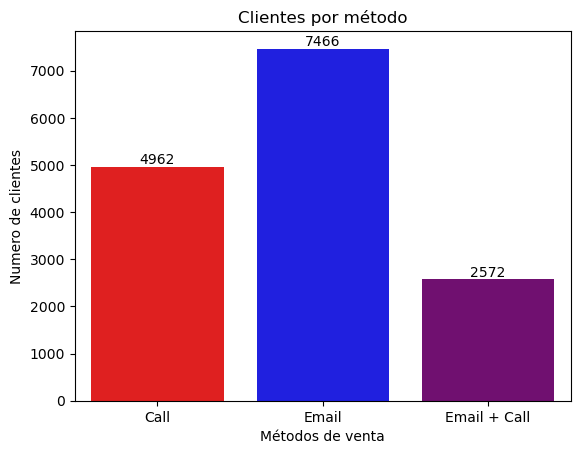

In [41]:
ax= sns.barplot(data=sales_count, x="sales_method", y='customer_id', hue="sales_method", palette=color_methods)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Clientes por método")
plt.xlabel("Métodos de venta")
plt.ylabel("Numero de clientes")
plt.show()

2. ¿Cómo es la distribución de los ingresos en general y para cada método?

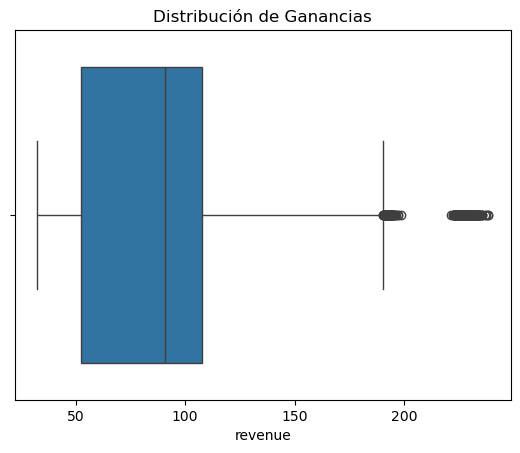

In [42]:
sns.boxplot(x = "revenue", data=sales)
plt.title("Distribución de Ganancias")
plt.show()

In [43]:
sales.groupby('sales_method')['revenue'].mean().round(2)

sales_method
Call             47.60
Email            97.13
Email + Call    183.65
Name: revenue, dtype: float64

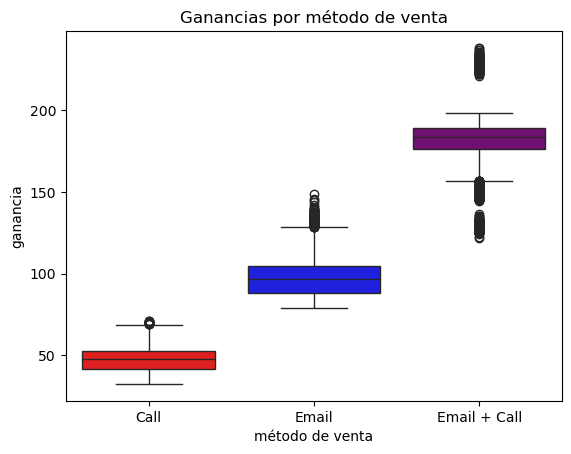

In [44]:
order = ["Call", "Email", "Email + Call"]

sns.boxplot(x="sales_method", y="revenue", data=sales, hue="sales_method", palette=color_methods, order=order)
plt.title("Ganancias por método de venta")
plt.xlabel("método de venta")
plt.ylabel("ganancia")
plt.show()

Total de revenue por metodo

In [45]:
sales.groupby('sales_method')['revenue'].sum().round(2)

sales_method
Call            236179.09
Email           725156.55
Email + Call    472350.54
Name: revenue, dtype: float64

3. ¿Hubo alguna diferencia en los ingresos a lo largo del tiempo para cada uno de los métodos?

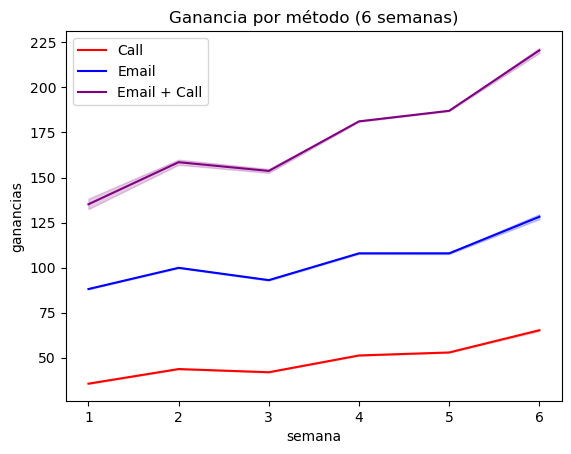

In [46]:
sns.lineplot(x="week", y="revenue", hue="sales_method", data=sales, palette=color_methods, hue_order=["Call", "Email", "Email + Call"])
plt.title("Ganancia por método (6 semanas)")
plt.xlabel("semana")
plt.ylabel("ganancias")
plt.legend()
plt.show()

Otras diferencias entre los clientes de cada grupo

La relación entre el método de ventas y el número de productos vendidos por cada venta

In [47]:
sales_sold = sales.groupby("sales_method")["nb_sold"].mean().reset_index()

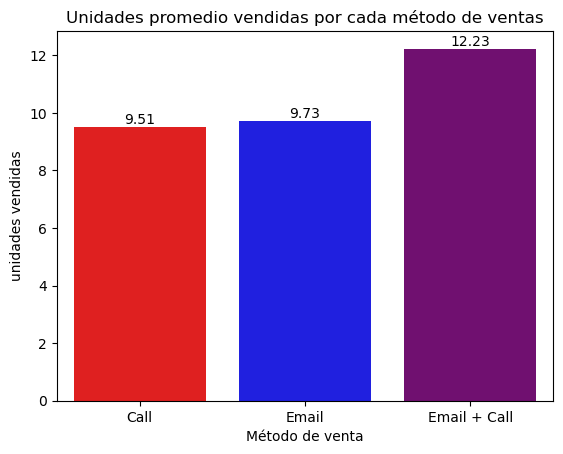

In [48]:
ax = sns.barplot(data=sales_sold,  x="sales_method", y='nb_sold', hue="sales_method", palette=color_methods)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
    
plt.title("Unidades promedio vendidas por cada método de ventas")
plt.xlabel("Método de venta")
plt.ylabel("unidades vendidas")
plt.show()

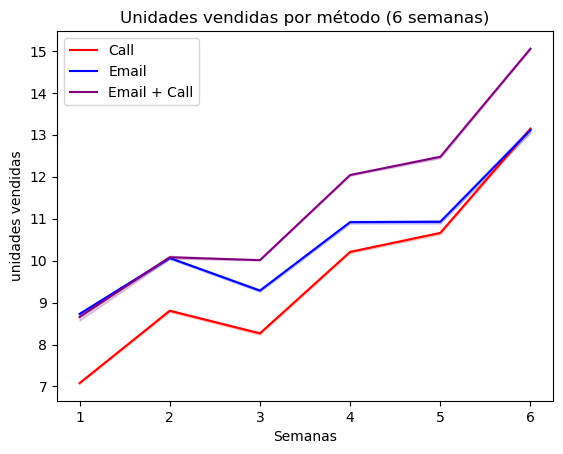

In [49]:
sns.lineplot(x="week", y="nb_sold", hue="sales_method", data=sales, palette=color_methods, hue_order=["Call", "Email", "Email + Call"])
plt.title("Unidades vendidas por método (6 semanas)")
plt.xlabel("Semanas")
plt.ylabel("unidades vendidas")
plt.legend()
plt.show()

Relación entre el método de ventas y las visitas al sitio web

In [50]:
visits_for_method = sales.groupby("sales_method")["nb_site_visits"].mean().reset_index()

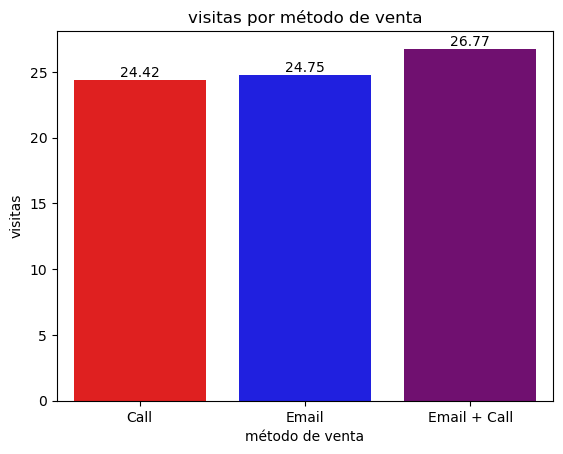

In [51]:
ax = sns.barplot(data=visits_for_method,  x="sales_method", y="nb_site_visits", hue="sales_method", palette=color_methods)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
    
plt.title("visitas por método de venta")
plt.xlabel("método de venta")
plt.ylabel("visitas")
plt.show()

## Hallazgos clave

La gran mayoría de nuestros clientes es contactada mediante el método de email; más de la mitad utiliza este canal, por lo que, en términos totales, es el que genera mayor revenue.

Sin embargo, si hablamos de promedios de revenue por cliente, el método Email + Call es por mucho mayor, casi duplicando el siguiente método, también destaca en las métricas de nb_sold y visitas al sitio web. 

Basado en esos resultados se recomienda usar el metodo de Email + Call como el metodo principal pero a continuación se dice como se deve revisar si esta teniendo el efecto esperado.

## Metrica para monitoriar

El promedio de Revenue

Monitoriarlo tanto a nivel global como a nivel de método de venta

Una versión más fluida y formal sería:

“A nivel global, se espera observar un aumento, ya que a medida que más clientes sean contactados mediante el método Email + Call, el promedio de revenue por venta será mayor, según los datos analizados.”

A nivel de método de venta, se debería observar un aumento en Email + Call o, al menos, que se mantenga estable, ya que, a medida que aumente el número de clientes en este método, incluso si su promedio se mantiene constante, el impacto global seguirá siendo positivo debido a su mayor promedio de revenue en comparación con los otros métodos.

# Recomendaciones

Es importante verificar que el número de clientes no disminuya al utilizar el método especificado, ya que una reducción podría afectar el revenue. Dado que los métodos Email y Email + Call parten de condiciones similares, la transición entre ambos es relativamente sencilla.

Se recomienda implementar el cambio de forma gradual para evaluar si la carga adicional de 10 minutos, al pasar de Email a Email + Call, no afecta negativamente a los trabajadores, o bien, determinar si es necesario contratar más personal, aunque esta carga podría compensarse con la disminución de 20 minutos del método Call.

Para lograr un mejor análisis, se recomienda especificar los productos vendidos en cada transacción. Asimismo, es importante evitar la presencia de datos faltantes en la columna de revenue, con el fin de prevenir errores en el análisis.